In [ ]:
'''pydantic is a python library for data validation and settings 
management that uses python type hints to enforce data integrity
at runtime '''


In [6]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

llm = ChatGroq(
    model = "llama-3.1-8b-instant"
)



### Pydantic Schema

In [8]:
from pydantic import BaseModel, Field 

class graph_schema(BaseModel):
    topic : str = Field(description = "The topic of the graph")
    post : str = Field(description = "The LinkedIn post content")
    curated_post : str = Field(desciription = "The curated LinkedIn post content" )

demo_obj = graph_schema(
    topic = "Artificial Intelligence",
    post = "Artificial Intelligence is transforming the world. It has applications in various fields such as healthcare, finance, and transportation. The future of AI looks promising with advancements in machine learning and deep learning.",
    curated_post = "Artificial Intelligence is revolutionizing the world with its applications in healthcare, finance and transportation. The future of AI is promising with advancements in machine learning and deep learning."      
    )

print(demo_obj)

topic='Artificial Intelligence' post='Artificial Intelligence is transforming the world. It has applications in various fields such as healthcare, finance, and transportation. The future of AI looks promising with advancements in machine learning and deep learning.' curated_post='Artificial Intelligence is revolutionizing the world with its applications in healthcare, finance and transportation. The future of AI is promising with advancements in machine learning and deep learning.'


C:\Users\harry\AppData\Local\Temp\ipykernel_9328\3600381330.py:6: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'desciription'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  curated_post : str = Field(desciription = "The curated LinkedIn post content" )


In [ ]:
def create_post(state:graph_schema):
    
    #convert the Pydatnic model to a dictionary 
    state = state.model_dump()

    #Extract the topic from the state
    topic = state['topic']

    #Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}").content

    state['post'] = post

    return state 

def curate_post(state:graph_schema):
    #convert the Pydatnic model to a dictionary 
    state = state.model_dump()

    #Extract the post from the state
    post = state['post']

    #Passing the post to the LLM to curate it for LinkedIn
    curated_post = llm.invoke(f"Curate the following LinkedIn post for better engagement : {post}").content

    state['curated_post'] = curated_post

    return state








In [11]:
from langgraph.graph import StateGraph , START , END

graph = StateGraph(graph_schema)

graph.add_node("create_post" , create_post)
graph.add_node("curate_post" , curate_post)

graph.add_edge(START , "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post" , END)

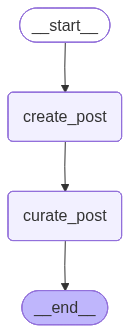

In [13]:
DGraph = graph.compile()
DGraph